# Task 3.1 — Load and Explore Fashion-MNIST

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)
Pixel value range: 0 to 255


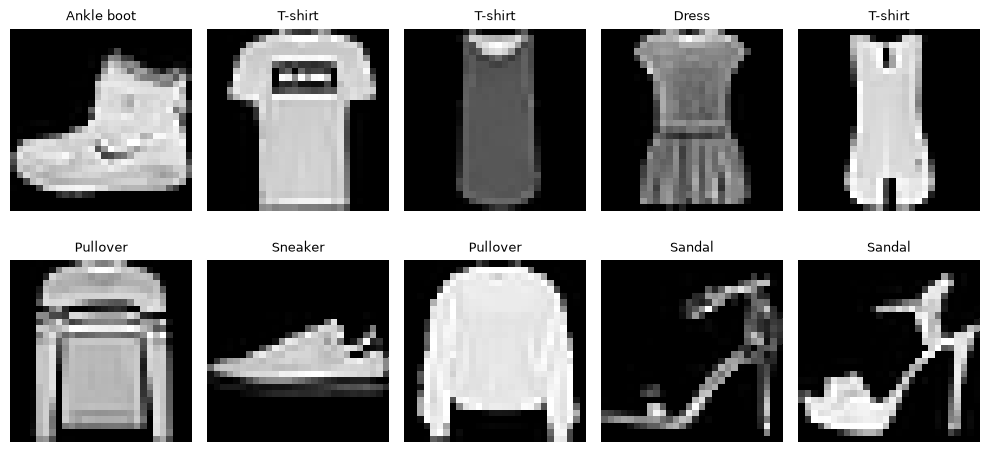

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Fashion-MNIST: 70,000 grayscale 28x28 images of clothing, 10 classes
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Pixel value range: {X_train.min()} to {X_train.max()}')

# Look at some examples
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', dpi=150)
plt.show()

# Task 3.2 — Preprocess the Images

In [2]:
# 1. Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. Add a channel dimension: (28, 28) -> (28, 28, 1)
#    Conv2D expects (height, width, channels)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

print(f'After preprocessing: {X_train.shape}')
print(f'New pixel range: {X_train.min()} to {X_train.max()}')

After preprocessing: (60000, 28, 28, 1)
New pixel range: 0.0 to 1.0


# Task 3.3 — Build the CNN

In [3]:
from tensorflow.keras import layers

# WHAT EACH LAYER DOES:
# Conv2D     -> slides small filters over the image to detect patterns
#               (edges, then shapes, then object parts as you go deeper)
# MaxPooling -> shrinks the image, keeps the strongest signals
# Flatten    -> converts the 2D feature maps into a 1D vector
# Dense      -> the classifier head that makes the final decision

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax'),  # 10 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # labels are ints, not one-hot
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3.4 — Train and Evaluate

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.7564 - loss: 0.6785 - val_accuracy: 0.8443 - val_loss: 0.4325
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8446 - loss: 0.4381 - val_accuracy: 0.8655 - val_loss: 0.3784
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8612 - loss: 0.3899 - val_accuracy: 0.8765 - val_loss: 0.3491
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8704 - loss: 0.3628 - val_accuracy: 0.8798 - val_loss: 0.3233
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8774 - loss: 0.3413 - val_accuracy: 0.8832 - val_loss: 0.3135
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8841 - loss: 0.3254 - val_accuracy: 0.8900 - val_loss: 0.2974
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8891 - loss: 0.3119 - val_accuracy: 0.8968 - val_loss: 0.2849
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8910 - loss: 0.3018 - val_ac

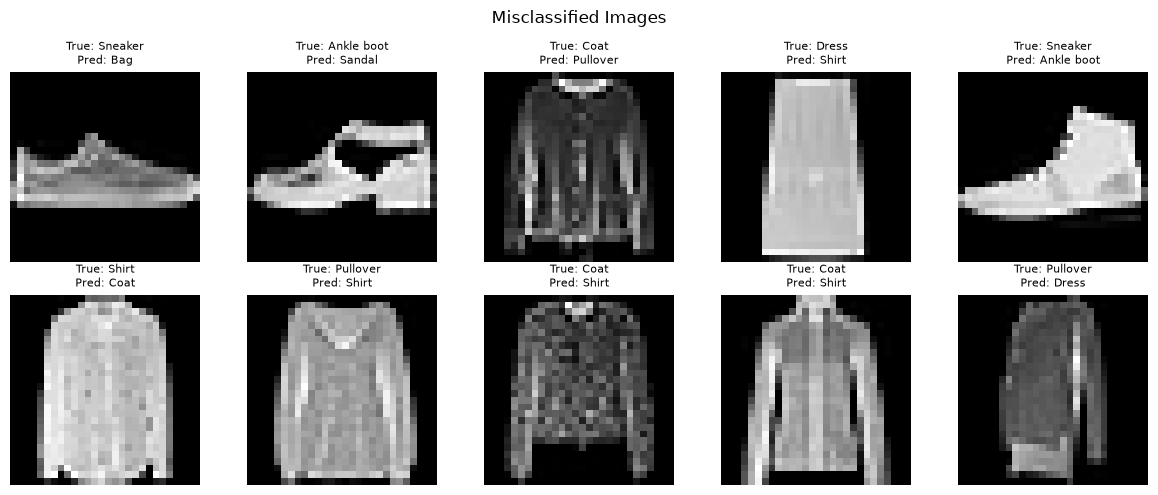

In [4]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')

# Look at some predictions - including mistakes
y_pred = model.predict(X_test).argmax(axis=1)
wrong = np.where(y_pred != y_test)[0][:10]

plt.figure(figsize=(12, 5))
for i, idx in enumerate(wrong):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title(f'True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}', fontsize=8)
    plt.axis('off')
plt.suptitle('Misclassified Images')
plt.tight_layout()
plt.savefig('cnn_mistakes.png', dpi=150)
plt.show()

## Analysis of Misclassified Images

The CNN reached a test accuracy of 0.8987 after 10 epochs, with training and
validation accuracy staying close together (0.899 vs 0.903) — no clear overfitting.

Looking at the misclassified samples, the errors are concentrated between visually
similar categories:
- Coat ↔ Pullover ↔ Shirt (all loose upper-body garments with similar silhouettes)
- Sneaker ↔ Bag / Ankle boot (similar overall shape at low resolution)

This makes sense: at 28x28 grayscale resolution, fine details like fabric texture
or exact cut are lost, so the model has to rely mostly on overall shape — and shape
alone isn't enough to separate these classes reliably.

Unlike Day 2's tabular model (which hit a suspicious 1.000 due to data leakage),
this result reflects the model genuinely learning visual patterns rather than
exploiting an artifact in the data.